<a href="https://colab.research.google.com/github/castrokelly/PPGIa/blob/main/atividade_2_lstm_transformer_emocoes_refatorado_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade 2 — Classificação de emoções com LSTM e Transformer

## Objetivo

Comparação entre duas arquiteturas para classificação de textos em português:

1. **LSTM**, com vocabulário e embeddings aprendidos na própria base;
2. **Transformer**, por ajuste fino do BERTimbau pré-treinado em português.

Duas tarefas são avaliadas:

- **classificação binária:** positivo e negativo;
- **classificação multiclasse:** alegria, tristeza, raiva, medo, desgosto, surpresa e neutro.

O protocolo principal segue o enunciado:

- concatenação das bases `g1_v1_ws.csv` e `g1_v2_ws.csv`;
- divisão holdout estratificada de 70% para treinamento e 30% para teste;
- mesma divisão de teste para LSTM e BERT em cada tarefa;
- apresentação de acurácia, F1 e matriz de confusão.

Uma parcela interna do conjunto de treinamento é reservada para early stopping e seleção da melhor época. A base externa de teste permanece isolada até a avaliação final.

## Referências metodológicas da disciplina

Estrutura baseada no notebook `Text_Classification_LSTM_emotions_binary.ipynb`:

- leitura e concatenação dos dois arquivos;
- criação da tarefa binária por agrupamento das emoções;
- tokenização, sequências de tamanho fixo e camada de embedding;
- uso de LSTM e matriz de confusão.

A organização também considera os materiais de RNN/LSTM e Transformer utilizados na disciplina:

- LSTM para modelagem de dependências sequenciais e redução do problema de vanishing gradient;
- tokenização, embeddings e contextualização pelo encoder Transformer;
- uso de BERT pré-treinado como ponto de partida para a classificação.

A remoção automática de stopwords não é aplicada. Termos como “não” podem alterar diretamente a polaridade e devem ser preservados.

## 1. Instalação das dependências

Uso do TensorFlow/Keras para a LSTM, PyTorch e Hugging Face Transformers para o BERTimbau, Scikit-learn para o protocolo holdout e as métricas, e ReportLab para a geração do relatório final.

In [1]:
%pip install -q \
    "tensorflow>=2.15,<2.21" \
    "pandas==2.2.2" \
    "transformers==4.57.6" \
    "huggingface-hub==0.36.2" \
    "sentencepiece>=0.2,<0.3" \
    reportlab

## 2. Importações e reprodutibilidade

Definição de sementes aleatórias para NumPy, TensorFlow, PyTorch e operações do Python. Preservação da GPU para o BERT por padrão, já que a base é pequena e a LSTM pode ser treinada em CPU sem custo elevado.

Alteração de `USAR_GPU_NA_LSTM` para `True` caso exista memória suficiente para manter TensorFlow e PyTorch na mesma GPU.

In [2]:
import os

# Configurações definidas antes da importação do TensorFlow.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "1"
os.environ["PYTHONHASHSEED"] = "42"

import gc
import re
import json
import time
import random
import warnings
import subprocess
from pathlib import Path
from math import ceil
from importlib.metadata import version as package_version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

SEMENTE = 42
USAR_GPU_NA_LSTM = False

random.seed(SEMENTE)
np.random.seed(SEMENTE)

import tensorflow as tf

# A LSTM utiliza CPU. A GPU permanece livre para o BERT, importado posteriormente.
if not USAR_GPU_NA_LSTM:
    try:
        tf.config.set_visible_devices([], "GPU")
    except RuntimeError as erro:
        raise RuntimeError(
            "O TensorFlow já inicializou a GPU. Reinicie a sessão e execute "
            "o notebook em ordem, sem importar PyTorch antes desta célula."
        ) from erro

from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(SEMENTE)

VERSOES_ESPERADAS = {
    "pandas": "2.2.2",
    "transformers": "4.57.6",
    "huggingface-hub": "0.36.2",
}

versoes_instaladas = {
    "pandas": pd.__version__,
    "transformers": package_version("transformers"),
    "huggingface-hub": package_version("huggingface-hub"),
    "torch": package_version("torch"),
}

for pacote, versao_esperada in VERSOES_ESPERADAS.items():
    versao_atual = versoes_instaladas[pacote]
    if versao_atual != versao_esperada:
        raise RuntimeError(
            f"Versão incompatível de {pacote}: {versao_atual}. "
            f"Versão exigida: {versao_esperada}. "
            "Reinicie a sessão após a instalação e execute novamente desde o início."
        )

print("TensorFlow:", tf.__version__)
print("Pandas:", versoes_instaladas["pandas"])
print("PyTorch instalado:", versoes_instaladas["torch"])
print("Transformers:", versoes_instaladas["transformers"])
print("Hugging Face Hub:", versoes_instaladas["huggingface-hub"])
print("GPU desativada no TensorFlow:", not USAR_GPU_NA_LSTM)

TensorFlow: 2.20.0
Pandas: 2.2.2
PyTorch instalado: 2.11.0+cu128
Transformers: 4.57.6
Hugging Face Hub: 0.36.2
GPU desativada no TensorFlow: True


## 3. Configuração da execução

Dois modos disponíveis:

- `MODO_RAPIDO=True`: validação do fluxo com amostra reduzida, menos épocas e encoder BERT congelado;
- `MODO_RAPIDO=False`: execução definitiva, com toda a base e ajuste fino do encoder.

Para obtenção dos resultados da atividade, uso recomendado de `MODO_RAPIDO=False` em ambiente Colab com GPU.

In [3]:
VERSAO_NOTEBOOK = "2.0.0"
MODO_RAPIDO = False

REMOVER_DUPLICATAS = True
REMOVER_TEXTOS_COM_ROTULOS_CONFLITANTES = True

MAX_TOKENS_LSTM = 10_000
TAMANHO_SEQUENCIA_LSTM = 60
DIMENSAO_EMBEDDING = 128
UNIDADES_LSTM = 64

MODELO_BERT = "neuralmind/bert-base-portuguese-cased"
TAMANHO_SEQUENCIA_BERT = 96

USAR_CACHE_NO_DRIVE = True
REUTILIZAR_MODELOS_EXISTENTES = False

if USAR_CACHE_NO_DRIVE:
    try:
        from google.colab import drive

        drive.mount(
            "/content/drive",
            force_remount=False,
        )

        PASTA_PERSISTENTE = (
            Path("/content/drive/MyDrive")
            / "atividade_2_lstm_transformer"
        )
    except ImportError:
        PASTA_PERSISTENTE = (
            Path.cwd()
            / "atividade_2_lstm_transformer"
        )
else:
    PASTA_PERSISTENTE = (
        Path.cwd()
        / "atividade_2_lstm_transformer"
    )

PASTA_CACHE = PASTA_PERSISTENTE / "cache"
PASTA_CACHE_HF = PASTA_CACHE / "huggingface"
PASTA_CACHE_TORCH = PASTA_CACHE / "torch"
PASTA_SAIDA = (
    PASTA_PERSISTENTE
    / "resultados"
    / f"v{VERSAO_NOTEBOOK}"
)

for pasta in [
    PASTA_CACHE_HF,
    PASTA_CACHE_TORCH,
    PASTA_SAIDA,
]:
    pasta.mkdir(
        parents=True,
        exist_ok=True,
    )

# Definição anterior à importação do Transformers e do PyTorch.
os.environ["HF_HOME"] = str(PASTA_CACHE_HF)
os.environ["HF_HUB_CACHE"] = str(PASTA_CACHE_HF / "hub")
os.environ["TRANSFORMERS_CACHE"] = str(PASTA_CACHE_HF / "transformers")
os.environ["TORCH_HOME"] = str(PASTA_CACHE_TORCH)

if MODO_RAPIDO:
    EPOCAS_LSTM = 5
    EPOCAS_BERT = 1
    BATCH_LSTM = 64
    BATCH_BERT = 16
    AMOSTRAS_POR_CLASSE = 150
    CONGELAR_ENCODER_BERT = True
else:
    EPOCAS_LSTM = 20
    EPOCAS_BERT = 3
    BATCH_LSTM = 64
    BATCH_BERT = 32
    AMOSTRAS_POR_CLASSE = None
    CONGELAR_ENCODER_BERT = False

GRADIENT_ACCUMULATION_STEPS = 1
TAXA_APRENDIZADO_BERT = 2e-5

print("Versão do notebook:", VERSAO_NOTEBOOK)
print("Modo rápido:", MODO_RAPIDO)
print("Encoder BERT congelado:", CONGELAR_ENCODER_BERT)
print("Cache Hugging Face:", PASTA_CACHE_HF)
print("Cache PyTorch:", PASTA_CACHE_TORCH)
print("Pasta de saída:", PASTA_SAIDA.resolve())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Versão do notebook: 2.0.0
Modo rápido: False
Encoder BERT congelado: False
Cache Hugging Face: /content/drive/MyDrive/atividade_2_lstm_transformer/cache/huggingface
Cache PyTorch: /content/drive/MyDrive/atividade_2_lstm_transformer/cache/torch
Pasta de saída: /content/drive/MyDrive/atividade_2_lstm_transformer/resultados/v2.0.0


## 4. Localização dos arquivos

Busca dos dois arquivos CSV no diretório atual, em `/content` e em `/mnt/data`. Caso os arquivos não sejam encontrados no Google Colab, abertura da caixa de upload.

In [4]:
caminhos = {
    "g1_v1_ws.csv": Path("/content/g1_v1_ws.csv"),
    "g1_v2_ws.csv": Path("/content/g1_v2_ws.csv"),
}

arquivos_ausentes = [
    str(caminho)
    for caminho in caminhos.values()
    if not caminho.exists()
]

if arquivos_ausentes:
    raise FileNotFoundError(
        "Arquivos não encontrados nos caminhos definidos: "
        + ", ".join(arquivos_ausentes)
    )

print(caminhos)

{'g1_v1_ws.csv': PosixPath('/content/g1_v1_ws.csv'), 'g1_v2_ws.csv': PosixPath('/content/g1_v2_ws.csv')}


## 5. Leitura e concatenação das bases

Leitura com separador `;` e codificação `cp1252`, compatível com os arquivos fornecidos. Remoção da coluna auxiliar constante `;`, preservação apenas de `texto` e `classe`, identificação da origem e concatenação vertical.

In [5]:
def carregar_base(caminho, origem):
    df = pd.read_csv(
        caminho,
        sep=";",
        encoding="cp1252",
        engine="python",
    )

    df.columns = [
        str(coluna).strip()
        for coluna in df.columns
    ]

    colunas_auxiliares = [
        coluna
        for coluna in df.columns
        if coluna not in {"texto", "classe"}
    ]

    if colunas_auxiliares:
        df = df.drop(columns=colunas_auxiliares)

    if not {"texto", "classe"}.issubset(df.columns):
        raise ValueError(
            f"Colunas esperadas não encontradas em {caminho}: {df.columns.tolist()}"
        )

    df = df[["texto", "classe"]].copy()
    df["origem"] = origem
    return df

df_v1 = carregar_base(
    caminhos["g1_v1_ws.csv"],
    "g1_v1_ws.csv",
)
df_v2 = carregar_base(
    caminhos["g1_v2_ws.csv"],
    "g1_v2_ws.csv",
)

df_bruto = pd.concat(
    [df_v1, df_v2],
    ignore_index=True,
)

print("Base v1:", df_v1.shape)
print("Base v2:", df_v2.shape)
print("Base concatenada:", df_bruto.shape)
display(df_bruto.head())

Base v1: (982, 3)
Base v2: (1750, 3)
Base concatenada: (2732, 3)


,texto,classe,origem
0,Ney Latorraca melhora e pode deixar CTI na sem...,alegria,g1_v1_ws.csv
1,Rato é encontrado em lata de feijões na França...,surpresa,g1_v1_ws.csv
2,Cientistas criam câmera mais rápida do mundo ...,alegria,g1_v1_ws.csv
3,Programa em MG aumenta uso de métodos anticon...,alegria,g1_v1_ws.csv
4,"Alencar é transferido para quarto, diz boleti...",alegria,g1_v1_ws.csv


## 6. Limpeza e auditoria

Normalização de espaços e nomes das classes, sem remoção de acentos, palavras funcionais ou pontuação no texto armazenado.

Tratamento opcional de dois problemas identificados nos arquivos:

- registros exatamente duplicados;
- textos associados a mais de uma emoção.

A remoção antes do holdout reduz o risco de uma mesma notícia aparecer simultaneamente no treinamento e no teste.

In [6]:
df = df_bruto.copy()

df["texto"] = (
    df["texto"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df["classe"] = (
    df["classe"]
    .astype(str)
    .str.strip()
    .str.lower()
)

nulos_antes = df[["texto", "classe"]].isna().sum().sum()
vazios_antes = (
    df["texto"].eq("").sum()
    + df["classe"].eq("").sum()
)

df = df.dropna(subset=["texto", "classe"])
df = df[
    df["texto"].ne("")
    & df["classe"].ne("")
].copy()

duplicatas_exatas = int(
    df.duplicated(
        subset=["texto", "classe"],
        keep="first",
    ).sum()
)

if REMOVER_DUPLICATAS:
    df = df.drop_duplicates(
        subset=["texto", "classe"],
        keep="first",
    ).copy()

quantidade_rotulos_por_texto = (
    df.groupby("texto")["classe"].nunique()
)

textos_conflitantes = quantidade_rotulos_por_texto[
    quantidade_rotulos_por_texto > 1
].index

n_textos_conflitantes = len(textos_conflitantes)

if REMOVER_TEXTOS_COM_ROTULOS_CONFLITANTES:
    df = df[
        ~df["texto"].isin(textos_conflitantes)
    ].copy()

df = df.reset_index(drop=True)

resumo_limpeza = pd.DataFrame({
    "item": [
        "Registros brutos",
        "Valores nulos encontrados",
        "Valores vazios encontrados",
        "Duplicatas exatas identificadas",
        "Textos com rótulos conflitantes",
        "Registros após limpeza",
    ],
    "quantidade": [
        len(df_bruto),
        int(nulos_antes),
        int(vazios_antes),
        duplicatas_exatas,
        n_textos_conflitantes,
        len(df),
    ],
})

display(resumo_limpeza)
display(
    df["classe"]
    .value_counts()
    .rename_axis("classe")
    .to_frame("quantidade")
)

,item,quantidade
0,Registros brutos,2732
1,Valores nulos encontrados,0
2,Valores vazios encontrados,0
3,Duplicatas exatas identificadas,287
4,Textos com rótulos conflitantes,3
5,Registros após limpeza,2439


,quantidade
classe,
alegria,604
tristeza,513
desgosto,481
neutro,226
medo,217
surpresa,202
raiva,196


## 7. Validação das classes e distribuição dos textos

Confirmação das sete emoções esperadas. Visualização da distribuição das classes e do tamanho dos textos em palavras.

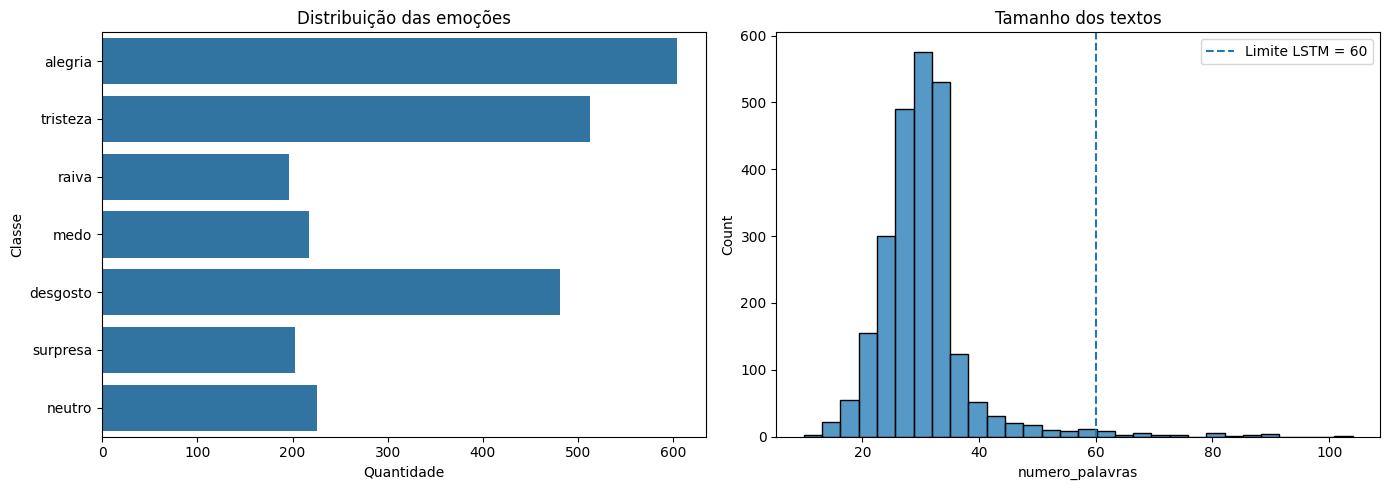

,numero_palavras
count,2439.000000
mean,30.318573
std,8.164517
min,10.000000
50%,29.000000
75%,33.000000
90%,37.000000
95%,43.000000
99%,64.620000
max,104.000000


In [7]:
CLASSES_ESPERADAS = {
    "alegria",
    "tristeza",
    "raiva",
    "medo",
    "desgosto",
    "surpresa",
    "neutro",
}

classes_encontradas = set(df["classe"].unique())

if classes_encontradas != CLASSES_ESPERADAS:
    raise ValueError(
        "Classes diferentes das esperadas. "
        f"Encontradas: {sorted(classes_encontradas)}"
    )

df["numero_palavras"] = (
    df["texto"]
    .str.split()
    .str.len()
)

fig, eixos = plt.subplots(1, 2, figsize=(14, 5))

ordem_classes = [
    "alegria",
    "tristeza",
    "raiva",
    "medo",
    "desgosto",
    "surpresa",
    "neutro",
]

sns.countplot(
    data=df,
    y="classe",
    order=ordem_classes,
    ax=eixos[0],
)
eixos[0].set_title("Distribuição das emoções")
eixos[0].set_xlabel("Quantidade")
eixos[0].set_ylabel("Classe")

sns.histplot(
    data=df,
    x="numero_palavras",
    bins=30,
    ax=eixos[1],
)
eixos[1].axvline(
    TAMANHO_SEQUENCIA_LSTM,
    linestyle="--",
    label=f"Limite LSTM = {TAMANHO_SEQUENCIA_LSTM}",
)
eixos[1].set_title("Tamanho dos textos")
eixos[1].legend()

plt.tight_layout()
plt.show()

display(
    df["numero_palavras"]
    .describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    )
    .to_frame()
)

## 8. Construção das tarefas

### Tarefa binária

Mapeamento preservado do exemplo utilizado em aula:

- **positivo:** neutro, alegria e surpresa;
- **negativo:** medo, raiva, desgosto e tristeza.

### Tarefa multiclasse

Preservação das sete emoções originais.

Codificação numérica fixa para manter a ordem das classes nas tabelas e matrizes de confusão.

In [8]:
MAPEAMENTO_BINARIO = {
    "neutro": "positivo",
    "alegria": "positivo",
    "surpresa": "positivo",
    "medo": "negativo",
    "raiva": "negativo",
    "desgosto": "negativo",
    "tristeza": "negativo",
}

ORDEM_BINARIA = ["negativo", "positivo"]
ORDEM_MULTICLASSE = [
    "alegria",
    "tristeza",
    "raiva",
    "medo",
    "desgosto",
    "surpresa",
    "neutro",
]

df["classe_binaria"] = (
    df["classe"]
    .map(MAPEAMENTO_BINARIO)
)

if df["classe_binaria"].isna().any():
    raise ValueError("Falha no mapeamento binário.")

display(
    df["classe_binaria"]
    .value_counts()
    .reindex(ORDEM_BINARIA)
    .to_frame("quantidade")
)

,quantidade
classe_binaria,
negativo,1407
positivo,1032


## 9. Holdout estratificado 70%/30%

Criação de uma divisão independente para cada tarefa, sempre com 70% para treinamento e 30% para teste.

Subdivisão posterior do treinamento em:

- treinamento interno;
- validação interna para early stopping.

A base de teste não participa da criação do vocabulário, escolha da época ou ajuste dos parâmetros.

In [9]:
def amostrar_por_classe(
    textos,
    rotulos,
    quantidade_por_classe,
    semente,
):
    if quantidade_por_classe is None:
        return textos, rotulos

    rng = np.random.default_rng(semente)
    textos = np.asarray(textos)
    rotulos = np.asarray(rotulos)

    indices = []

    for classe in np.unique(rotulos):
        candidatos = np.flatnonzero(
            rotulos == classe
        )
        n = min(
            quantidade_por_classe,
            len(candidatos),
        )
        indices.extend(
            rng.choice(
                candidatos,
                size=n,
                replace=False,
            )
        )

    indices = np.asarray(indices)
    rng.shuffle(indices)

    return textos[indices], rotulos[indices]

def preparar_tarefa(
    nome,
    coluna_alvo,
    ordem_classes,
):
    textos = df["texto"].to_numpy()
    rotulos_texto = df[coluna_alvo].to_numpy()

    mapa_classe_id = {
        classe: indice
        for indice, classe in enumerate(ordem_classes)
    }

    rotulos = np.asarray([
        mapa_classe_id[classe]
        for classe in rotulos_texto
    ])

    textos, rotulos = amostrar_por_classe(
        textos,
        rotulos,
        AMOSTRAS_POR_CLASSE,
        SEMENTE,
    )

    (
        textos_treino_total,
        textos_teste,
        y_treino_total,
        y_teste,
    ) = train_test_split(
        textos,
        rotulos,
        test_size=0.30,
        random_state=SEMENTE,
        stratify=rotulos,
    )

    (
        textos_treino,
        textos_validacao,
        y_treino,
        y_validacao,
    ) = train_test_split(
        textos_treino_total,
        y_treino_total,
        test_size=0.15,
        random_state=SEMENTE,
        stratify=y_treino_total,
    )

    sobreposicao = (
        set(textos_treino_total)
        .intersection(set(textos_teste))
    )

    if sobreposicao:
        raise ValueError(
            f"Sobreposição entre treino e teste na tarefa {nome}: "
            f"{len(sobreposicao)} textos."
        )

    return {
        "nome": nome,
        "classes": ordem_classes,
        "mapa_classe_id": mapa_classe_id,
        "textos_treino_total": textos_treino_total,
        "y_treino_total": y_treino_total,
        "textos_treino": textos_treino,
        "y_treino": y_treino,
        "textos_validacao": textos_validacao,
        "y_validacao": y_validacao,
        "textos_teste": textos_teste,
        "y_teste": y_teste,
    }

tarefas = {
    "binaria": preparar_tarefa(
        nome="Classificação binária",
        coluna_alvo="classe_binaria",
        ordem_classes=ORDEM_BINARIA,
    ),
    "multiclasse": preparar_tarefa(
        nome="Classificação multiclasse",
        coluna_alvo="classe",
        ordem_classes=ORDEM_MULTICLASSE,
    ),
}

resumo_splits = []

for chave, tarefa in tarefas.items():
    resumo_splits.append({
        "tarefa": chave,
        "treino_holdout_70": len(
            tarefa["textos_treino_total"]
        ),
        "treino_interno": len(
            tarefa["textos_treino"]
        ),
        "validacao_interna": len(
            tarefa["textos_validacao"]
        ),
        "teste_holdout_30": len(
            tarefa["textos_teste"]
        ),
        "numero_classes": len(
            tarefa["classes"]
        ),
    })

display(pd.DataFrame(resumo_splits))

,tarefa,treino_holdout_70,treino_interno,validacao_interna,teste_holdout_30,numero_classes
0,binaria,1707,1450,257,732,2
1,multiclasse,1707,1450,257,732,7


## 10. Funções de métricas e matriz de confusão

Uso de:

- acurácia;
- F1 macro como métrica principal de equilíbrio entre as classes;
- F1 ponderado como medida complementar;
- precisão e recall macro;
- matriz de confusão em contagens absolutas.

O F1 macro evita que as classes mais frequentes dominem a comparação multiclasse.

In [10]:
resultados = []
predicoes = {}
historicos = {}

def calcular_metricas(
    y_real,
    y_predito,
):
    return {
        "acuracia": accuracy_score(
            y_real,
            y_predito,
        ),
        "f1_macro": f1_score(
            y_real,
            y_predito,
            average="macro",
            zero_division=0,
        ),
        "f1_ponderado": f1_score(
            y_real,
            y_predito,
            average="weighted",
            zero_division=0,
        ),
        "precisao_macro": precision_score(
            y_real,
            y_predito,
            average="macro",
            zero_division=0,
        ),
        "recall_macro": recall_score(
            y_real,
            y_predito,
            average="macro",
            zero_division=0,
        ),
    }

def nome_seguro(texto):
    return re.sub(
        r"[^a-zA-Z0-9_-]+",
        "_",
        texto,
    ).strip("_")

def salvar_matriz_confusao(
    tarefa,
    modelo,
    y_real,
    y_predito,
    classes,
):
    matriz = confusion_matrix(
        y_real,
        y_predito,
        labels=np.arange(len(classes)),
    )

    plt.figure(
        figsize=(
            6 if len(classes) == 2 else 10,
            5 if len(classes) == 2 else 8,
        )
    )

    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
    )

    plt.xlabel("Classe predita")
    plt.ylabel("Classe real")
    plt.title(
        f"Matriz de confusão — {modelo} — {tarefa}"
    )
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    caminho = (
        PASTA_SAIDA
        / f"matriz_{nome_seguro(tarefa)}_{nome_seguro(modelo)}.png"
    )

    plt.savefig(
        caminho,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()

    return matriz, caminho

def persistir_resultados_parciais():
    if resultados:
        (
            pd.DataFrame(resultados)
            .drop_duplicates(
                subset=["tarefa", "modelo"],
                keep="last",
            )
            .to_csv(
                PASTA_SAIDA / "resultados_parciais.csv",
                index=False,
            )
        )

    if predicoes:
        np.savez_compressed(
            PASTA_SAIDA / "predicoes_parciais.npz",
            **{
                f"{tarefa}__{modelo}": valores
                for (tarefa, modelo), valores
                in predicoes.items()
            },
        )

def registrar_resultado(
    chave_tarefa,
    modelo,
    y_real,
    y_predito,
    tempo_segundos,
    observacoes,
):
    tarefa = tarefas[chave_tarefa]
    metricas = calcular_metricas(
        y_real,
        y_predito,
    )

    matriz, caminho_matriz = (
        salvar_matriz_confusao(
            tarefa=tarefa["nome"],
            modelo=modelo,
            y_real=y_real,
            y_predito=y_predito,
            classes=tarefa["classes"],
        )
    )

    linha = {
        "tarefa": chave_tarefa,
        "descricao_tarefa": tarefa["nome"],
        "modelo": modelo,
        **metricas,
        "tempo_segundos": tempo_segundos,
        "observacoes": observacoes,
        "caminho_matriz": str(caminho_matriz),
    }

    resultados[:] = [
        item
        for item in resultados
        if not (
            item["tarefa"] == chave_tarefa
            and item["modelo"] == modelo
        )
    ]
    resultados.append(linha)

    predicoes[(chave_tarefa, modelo)] = (
        np.asarray(y_predito)
    )

    persistir_resultados_parciais()

    print(
        classification_report(
            y_real,
            y_predito,
            target_names=tarefa["classes"],
            zero_division=0,
        )
    )

    return linha

# Parte A — Modelos LSTM

## 11. Vetorização e arquitetura

Uso de `TextVectorization` adaptado exclusivamente ao treinamento interno. Conversão dos textos em sequências de até 60 tokens e uso de token fora do vocabulário.

Arquitetura:

- embedding treinável;
- Spatial Dropout;
- duas camadas LSTM bidirecionais;
- camada densa;
- saída softmax com duas ou sete unidades.

A LSTM bidirecional considera o contexto anterior e posterior dentro da sentença.

In [11]:
def para_tensor_texto(textos):
    """
    Converte uma coleção de textos para um tensor TensorFlow
    com dtype tf.string, evitando arrays NumPy Unicode de
    largura fixa, como str19456.
    """
    return tf.convert_to_tensor(
        [str(texto) for texto in textos],
        dtype=tf.string,
    )


def criar_modelo_lstm(
    textos_treino,
    numero_classes,
):
    keras.utils.set_random_seed(SEMENTE)

    vetorizador = layers.TextVectorization(
        max_tokens=MAX_TOKENS_LSTM,
        standardize="lower_and_strip_punctuation",
        split="whitespace",
        output_mode="int",
        output_sequence_length=TAMANHO_SEQUENCIA_LSTM,
        name="text_vectorization",
    )

    tensor_textos_treino = para_tensor_texto(
        textos_treino
    )

    dataset_vocabulario = (
        tf.data.Dataset
        .from_tensor_slices(
            tensor_textos_treino
        )
        .batch(64)
    )

    vetorizador.adapt(
        dataset_vocabulario
    )

    tamanho_vocabulario = len(
        vetorizador.get_vocabulary()
    )

    # Uma string escalar por exemplo.
    entradas = keras.Input(
        shape=(),
        dtype=tf.string,
        name="texto",
    )

    x = vetorizador(
        entradas
    )

    x = layers.Embedding(
        input_dim=tamanho_vocabulario,
        output_dim=DIMENSAO_EMBEDDING,
        mask_zero=True,
        name="embedding",
    )(x)

    x = layers.SpatialDropout1D(
        0.20
    )(x)

    x = layers.Bidirectional(
        layers.LSTM(
            UNIDADES_LSTM,
            return_sequences=True,
            dropout=0.25,
        )
    )(x)

    x = layers.Bidirectional(
        layers.LSTM(
            UNIDADES_LSTM // 2,
            dropout=0.25,
        )
    )(x)

    x = layers.Dense(
        64,
        activation="relu",
    )(x)

    x = layers.Dropout(
        0.35
    )(x)

    saidas = layers.Dense(
        numero_classes,
        activation="softmax",
        name="classe",
    )(x)

    modelo = keras.Model(
        entradas,
        saidas,
        name="classificador_lstm",
    )

    modelo.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3,
        ),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )

    return modelo, vetorizador


def criar_pesos_classes(y_treino):
    classes = np.unique(
        y_treino
    )

    pesos = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_treino,
    )

    return {
        int(classe): float(peso)
        for classe, peso in zip(
            classes,
            pesos,
        )
    }

## 12. Treinamento e avaliação da LSTM

Treinamento separado para as tarefas binária e multiclasse. Uso de pesos de classe, early stopping por perda de validação e redução automática da taxa de aprendizado.


Treinamento LSTM: binaria
Epoch 1/20
23/23 - 4s - 166ms/step - accuracy: 0.5221 - loss: 0.6924 - val_accuracy: 0.6654 - val_loss: 0.6875 - learning_rate: 0.0010
Epoch 2/20
23/23 - 1s - 36ms/step - accuracy: 0.7503 - loss: 0.5876 - val_accuracy: 0.7471 - val_loss: 0.6226 - learning_rate: 0.0010
Epoch 3/20
23/23 - 1s - 32ms/step - accuracy: 0.9152 - loss: 0.2231 - val_accuracy: 0.7588 - val_loss: 0.6473 - learning_rate: 0.0010
Epoch 4/20

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
23/23 - 1s - 32ms/step - accuracy: 0.9572 - loss: 0.1300 - val_accuracy: 0.7549 - val_loss: 0.6987 - learning_rate: 0.0010
Epoch 5/20
23/23 - 1s - 30ms/step - accuracy: 0.9690 - loss: 0.0793 - val_accuracy: 0.7860 - val_loss: 0.9188 - learning_rate: 5.0000e-04
Epoch 6/20

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
23/23 - 1s - 31ms/step - accuracy: 0.9621 - loss: 0.0863 - val_accuracy: 0.7782 - val_loss: 0.7774 - learning_rate: 5.0000e-04
Epoch 

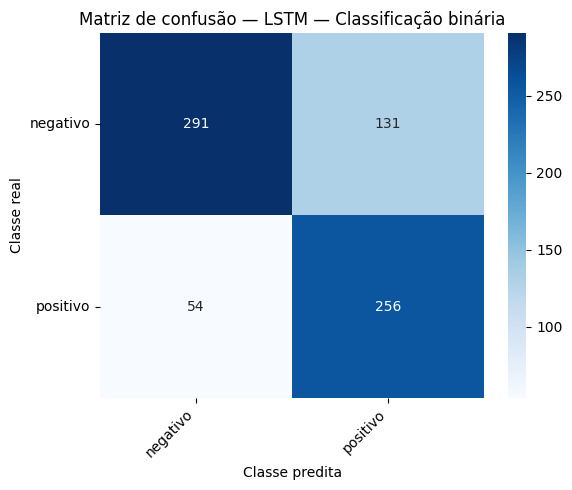

              precision    recall  f1-score   support

    negativo       0.84      0.69      0.76       422
    positivo       0.66      0.83      0.73       310

    accuracy                           0.75       732
   macro avg       0.75      0.76      0.75       732
weighted avg       0.77      0.75      0.75       732


Treinamento LSTM: multiclasse
Epoch 1/20
23/23 - 4s - 164ms/step - accuracy: 0.1379 - loss: 1.9446 - val_accuracy: 0.2335 - val_loss: 1.9407 - learning_rate: 0.0010
Epoch 2/20
23/23 - 1s - 35ms/step - accuracy: 0.2255 - loss: 1.8670 - val_accuracy: 0.2062 - val_loss: 1.8605 - learning_rate: 0.0010
Epoch 3/20
23/23 - 1s - 32ms/step - accuracy: 0.2800 - loss: 1.5945 - val_accuracy: 0.2568 - val_loss: 1.8609 - learning_rate: 0.0010
Epoch 4/20

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
23/23 - 1s - 32ms/step - accuracy: 0.3938 - loss: 1.3912 - val_accuracy: 0.3813 - val_loss: 1.9174 - learning_rate: 0.0010
Epoch 5/20
23/23 - 1s - 32ms

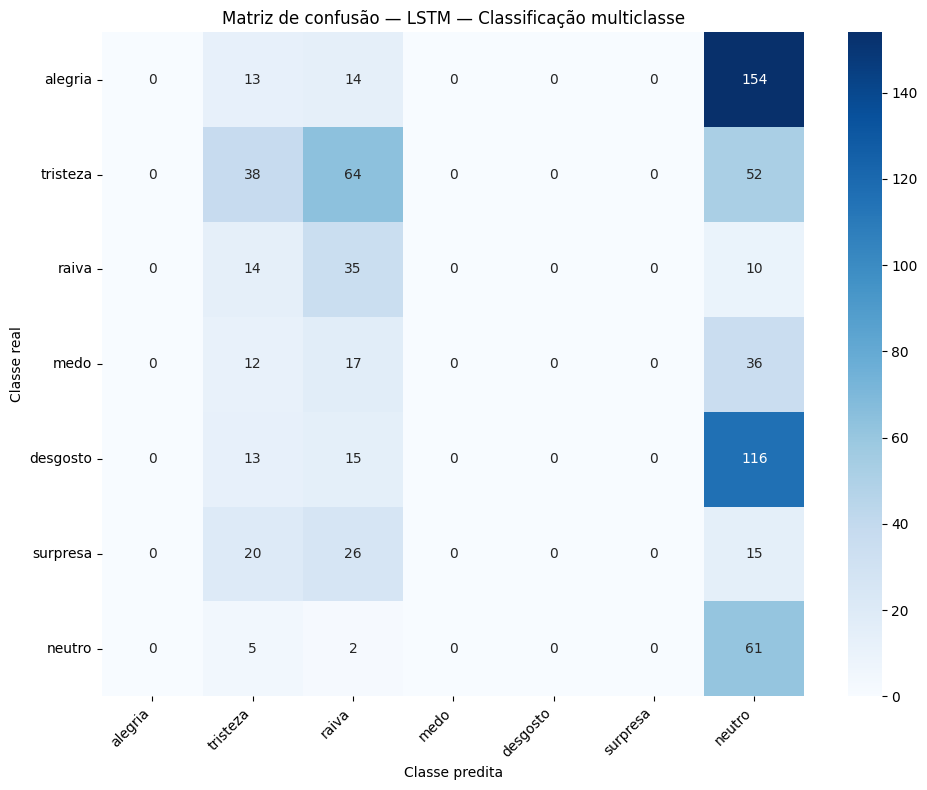

              precision    recall  f1-score   support

     alegria       0.00      0.00      0.00       181
    tristeza       0.33      0.25      0.28       154
       raiva       0.20      0.59      0.30        59
        medo       0.00      0.00      0.00        65
    desgosto       0.00      0.00      0.00       144
    surpresa       0.00      0.00      0.00        61
      neutro       0.14      0.90      0.24        68

    accuracy                           0.18       732
   macro avg       0.10      0.25      0.12       732
weighted avg       0.10      0.18      0.11       732



In [12]:
def treinar_e_avaliar_lstm(
    chave_tarefa,
):
    tarefa = tarefas[chave_tarefa]

    numero_classes = len(
        tarefa["classes"]
    )

    keras.backend.clear_session()
    gc.collect()

    caminho_modelo = (
        PASTA_SAIDA
        / f"lstm_{chave_tarefa}.keras"
    )

    caminho_checkpoint = (
        PASTA_SAIDA
        / f"lstm_{chave_tarefa}_melhor.keras"
    )

    caminho_log = (
        PASTA_SAIDA
        / f"lstm_{chave_tarefa}_treinamento.csv"
    )

    caminho_backup = (
        PASTA_SAIDA
        / f"backup_lstm_{chave_tarefa}"
    )

    # Conversão explícita para tensores tf.string.
    x_treino_lstm = para_tensor_texto(
        tarefa["textos_treino"]
    )

    x_validacao_lstm = para_tensor_texto(
        tarefa["textos_validacao"]
    )

    x_teste_lstm = para_tensor_texto(
        tarefa["textos_teste"]
    )

    if (
        REUTILIZAR_MODELOS_EXISTENTES
        and caminho_modelo.exists()
    ):
        modelo = keras.models.load_model(
            caminho_modelo
        )

        vetorizador = modelo.get_layer(
            "text_vectorization"
        )

        historico_dict = {}
        tempo = 0.0

    else:
        modelo, vetorizador = (
            criar_modelo_lstm(
                textos_treino=tarefa["textos_treino"],
                numero_classes=numero_classes,
            )
        )

        pesos_classes = criar_pesos_classes(
            tarefa["y_treino"]
        )

        callbacks = [
            keras.callbacks.ModelCheckpoint(
                filepath=str(
                    caminho_checkpoint
                ),
                monitor="val_loss",
                mode="min",
                save_best_only=True,
                verbose=0,
            ),
            keras.callbacks.BackupAndRestore(
                backup_dir=str(
                    caminho_backup
                ),
            ),
            keras.callbacks.CSVLogger(
                str(caminho_log),
                append=False,
            ),
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=4,
                restore_best_weights=True,
                verbose=1,
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=2,
                min_lr=1e-5,
                verbose=1,
            ),
        ]

        inicio = time.perf_counter()

        historico = modelo.fit(
            x_treino_lstm,
            tarefa["y_treino"],
            validation_data=(
                x_validacao_lstm,
                tarefa["y_validacao"],
            ),
            epochs=EPOCAS_LSTM,
            batch_size=BATCH_LSTM,
            class_weight=pesos_classes,
            callbacks=callbacks,
            verbose=2,
        )

        tempo = (
            time.perf_counter()
            - inicio
        )

        if caminho_checkpoint.exists():
            modelo = keras.models.load_model(
                caminho_checkpoint
            )

        modelo.save(
            caminho_modelo
        )

        historico_dict = (
            historico.history
        )

    probabilidades = modelo.predict(
        x_teste_lstm,
        batch_size=BATCH_LSTM,
        verbose=0,
    )

    y_predito = probabilidades.argmax(
        axis=1
    )

    historicos[
        (chave_tarefa, "LSTM")
    ] = historico_dict

    linha = registrar_resultado(
        chave_tarefa=chave_tarefa,
        modelo="LSTM",
        y_real=tarefa["y_teste"],
        y_predito=y_predito,
        tempo_segundos=tempo,
        observacoes=(
            "TextVectorization, embedding treinável, "
            "duas LSTMs bidirecionais e pesos de classe."
        ),
    )

    return modelo, vetorizador, linha


modelos_lstm = {}

for chave_tarefa in [
    "binaria",
    "multiclasse",
]:
    print(
        "\n",
        "=" * 80,
        "\nTreinamento LSTM:",
        chave_tarefa,
    )

    (
        modelo,
        vetorizador,
        linha,
    ) = treinar_e_avaliar_lstm(
        chave_tarefa
    )

    modelos_lstm[chave_tarefa] = {
        "modelo": modelo,
        "vetorizador": vetorizador,
        "resultado": linha,
    }

## 13. Curvas de treinamento das LSTMs

Visualização da acurácia e da perda de treinamento e validação para análise de convergência e overfitting.

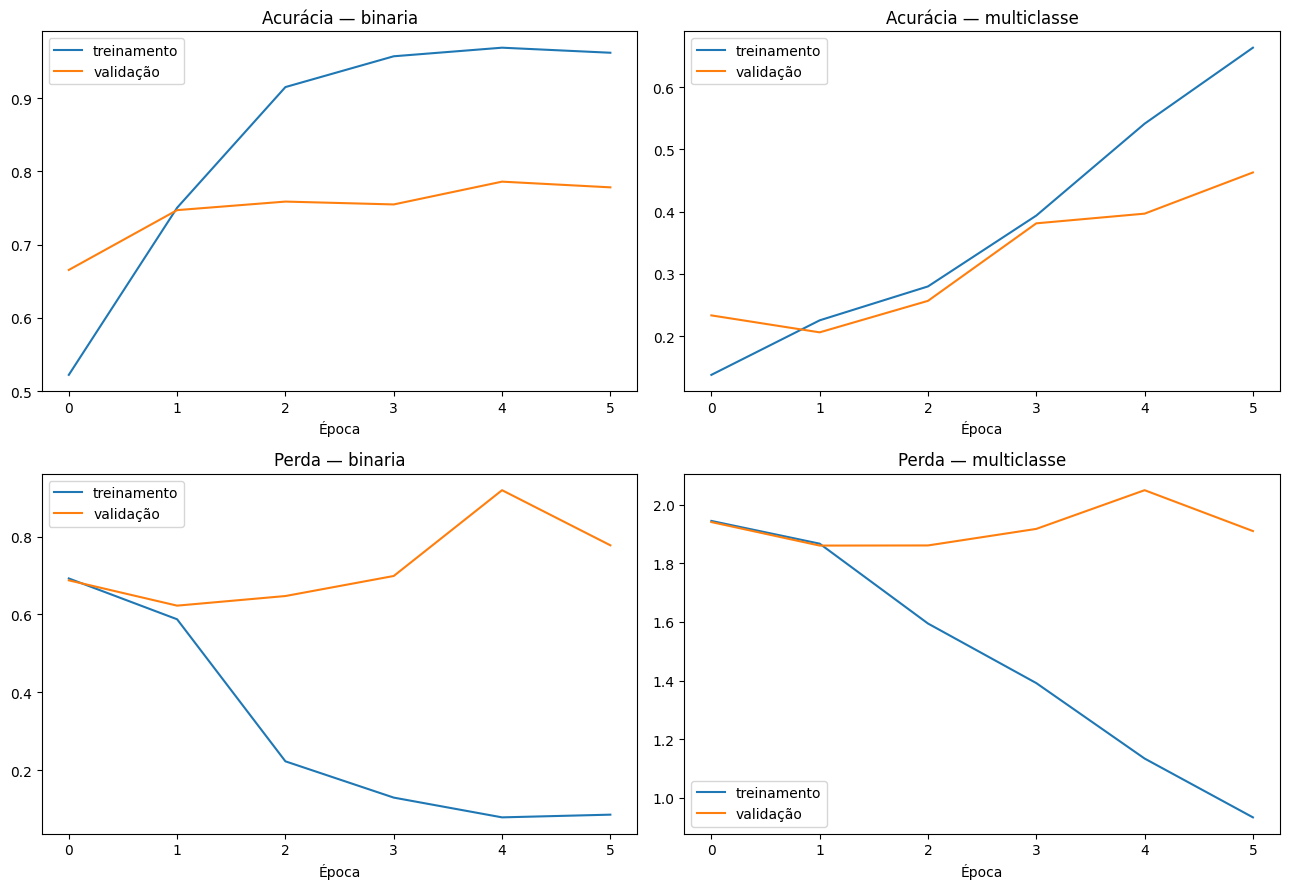

In [13]:
fig, eixos = plt.subplots(
    2,
    2,
    figsize=(13, 9),
)

for coluna, chave_tarefa in enumerate([
    "binaria",
    "multiclasse",
]):
    historico = historicos[
        (chave_tarefa, "LSTM")
    ]

    eixos[0, coluna].plot(
        historico["accuracy"],
        label="treinamento",
    )
    eixos[0, coluna].plot(
        historico["val_accuracy"],
        label="validação",
    )
    eixos[0, coluna].set_title(
        f"Acurácia — {chave_tarefa}"
    )
    eixos[0, coluna].set_xlabel(
        "Época"
    )
    eixos[0, coluna].legend()

    eixos[1, coluna].plot(
        historico["loss"],
        label="treinamento",
    )
    eixos[1, coluna].plot(
        historico["val_loss"],
        label="validação",
    )
    eixos[1, coluna].set_title(
        f"Perda — {chave_tarefa}"
    )
    eixos[1, coluna].set_xlabel(
        "Época"
    )
    eixos[1, coluna].legend()

plt.tight_layout()
plt.show()

# Parte B — Transformer BERTimbau

## 14. Tokenizador e modelo pré-treinado

Uso do modelo `neuralmind/bert-base-portuguese-cased`, pré-treinado para português.

O tokenizador WordPiece produz:

- identificadores dos tokens;
- máscara de atenção;
- truncamento e padding até 96 tokens.

No modo completo, ajuste fino de todo o encoder. No modo rápido, congelamento do encoder e treinamento apenas da cabeça de classificação.

In [14]:
# Liberação dos modelos TensorFlow antes de inicializar a GPU pelo PyTorch.
modelos_lstm.clear()
keras.backend.clear_session()
gc.collect()

import torch
import transformers
from torch.utils.data import (
    Dataset,
    DataLoader,
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from tqdm.auto import tqdm

torch.manual_seed(SEMENTE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEMENTE)
    torch.set_float32_matmul_precision("high")

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DISPOSITIVO = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

if DISPOSITIVO.type == "cuda":
    NOME_GPU = torch.cuda.get_device_name(0)
    VRAM_GB = (
        torch.cuda.get_device_properties(0).total_memory
        / 1024**3
    )
else:
    NOME_GPU = "CPU"
    VRAM_GB = 0.0

tokenizador_bert = (
    AutoTokenizer.from_pretrained(
        MODELO_BERT,
        cache_dir=str(
            PASTA_CACHE_HF / "hub"
        ),
    )
)

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Dispositivo:", DISPOSITIVO)
print("GPU:", NOME_GPU)
print(f"VRAM: {VRAM_GB:.1f} GB")
print("Modelo:", MODELO_BERT)
print("Cache:", PASTA_CACHE_HF)

/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

PyTorch: 2.11.0+cu128
Transformers: 4.57.6
Dispositivo: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM: 95.0 GB
Modelo: neuralmind/bert-base-portuguese-cased
Cache: /content/drive/MyDrive/atividade_2_lstm_transformer/cache/huggingface


## 15. Dataset tokenizado para o BERT

Tokenização executada uma única vez para cada divisão. Armazenamento dos tensores de `input_ids`, `attention_mask` e rótulos.

In [15]:
class DatasetBERT(Dataset):
    def __init__(
        self,
        textos,
        rotulos,
        tokenizador,
        tamanho_maximo,
    ):
        self.codificacoes = tokenizador(
            list(map(str, textos)),
            truncation=True,
            padding="max_length",
            max_length=tamanho_maximo,
            return_tensors="pt",
        )

        self.rotulos = torch.tensor(
            rotulos,
            dtype=torch.long,
        )

    def __len__(self):
        return len(self.rotulos)

    def __getitem__(self, indice):
        item = {
            chave: valor[indice]
            for chave, valor
            in self.codificacoes.items()
        }

        item["labels"] = (
            self.rotulos[indice]
        )

        return item

def criar_loaders_bert(tarefa):
    dataset_treino = DatasetBERT(
        textos=tarefa["textos_treino"],
        rotulos=tarefa["y_treino"],
        tokenizador=tokenizador_bert,
        tamanho_maximo=TAMANHO_SEQUENCIA_BERT,
    )

    dataset_validacao = DatasetBERT(
        textos=tarefa["textos_validacao"],
        rotulos=tarefa["y_validacao"],
        tokenizador=tokenizador_bert,
        tamanho_maximo=TAMANHO_SEQUENCIA_BERT,
    )

    dataset_teste = DatasetBERT(
        textos=tarefa["textos_teste"],
        rotulos=tarefa["y_teste"],
        tokenizador=tokenizador_bert,
        tamanho_maximo=TAMANHO_SEQUENCIA_BERT,
    )

    loader_treino = DataLoader(
        dataset_treino,
        batch_size=BATCH_BERT,
        shuffle=True,
        num_workers=0,
        pin_memory=DISPOSITIVO.type == "cuda",
    )

    loader_validacao = DataLoader(
        dataset_validacao,
        batch_size=BATCH_BERT,
        shuffle=False,
        num_workers=0,
        pin_memory=DISPOSITIVO.type == "cuda",
    )

    loader_teste = DataLoader(
        dataset_teste,
        batch_size=BATCH_BERT,
        shuffle=False,
        num_workers=0,
        pin_memory=DISPOSITIVO.type == "cuda",
    )

    return (
        loader_treino,
        loader_validacao,
        loader_teste,
    )

## 16. Funções de treinamento e avaliação do BERT

Uso de:

- AdamW;
- taxa de aprendizado de `2e-5`;
- warmup linear;
- mixed precision em GPU;
- clipping de gradiente;
- perda ponderada pelas frequências das classes;
- seleção da melhor época pelo F1 macro de validação.

In [16]:
def avaliar_bert(
    modelo,
    loader,
):
    modelo.eval()

    rotulos_reais = []
    predicoes_modelo = []
    perdas = []

    criterio = torch.nn.CrossEntropyLoss()

    usar_cuda = DISPOSITIVO.type == "cuda"
    tipo_amp = (
        torch.bfloat16
        if usar_cuda
        and torch.cuda.is_bf16_supported()
        else torch.float16
    )

    with torch.inference_mode():
        for batch in loader:
            labels = batch.pop(
                "labels"
            ).to(
                DISPOSITIVO,
                non_blocking=usar_cuda,
            )

            entradas = {
                chave: valor.to(
                    DISPOSITIVO,
                    non_blocking=usar_cuda,
                )
                for chave, valor
                in batch.items()
            }

            with torch.amp.autocast(
                "cuda",
                dtype=tipo_amp,
                enabled=usar_cuda,
            ):
                saida = modelo(**entradas)
                logits = saida.logits

                perda = criterio(
                    logits,
                    labels,
                )

            perdas.append(
                float(perda.detach().cpu())
            )

            predicoes_modelo.extend(
                logits.argmax(
                    dim=1
                )
                .cpu()
                .numpy()
            )

            rotulos_reais.extend(
                labels.cpu().numpy()
            )

    rotulos_reais = np.asarray(
        rotulos_reais
    )
    predicoes_modelo = np.asarray(
        predicoes_modelo
    )

    metricas = calcular_metricas(
        rotulos_reais,
        predicoes_modelo,
    )

    return {
        "perda": float(
            np.mean(perdas)
        ),
        "y_real": rotulos_reais,
        "y_predito": predicoes_modelo,
        **metricas,
    }

def treinar_bert(
    chave_tarefa,
):
    tarefa = tarefas[chave_tarefa]
    numero_classes = len(
        tarefa["classes"]
    )

    (
        loader_treino,
        loader_validacao,
        loader_teste,
    ) = criar_loaders_bert(
        tarefa
    )

    caminho_modelo = (
        PASTA_SAIDA
        / f"bert_{chave_tarefa}.pt"
    )
    caminho_historico = (
        PASTA_SAIDA
        / f"bert_{chave_tarefa}_historico.json"
    )
    caminho_loading_info = (
        PASTA_SAIDA
        / f"bert_{chave_tarefa}_loading_info.json"
    )

    modelo, info_carregamento = (
        AutoModelForSequenceClassification
        .from_pretrained(
            MODELO_BERT,
            num_labels=numero_classes,
            id2label={
                i: classe
                for i, classe
                in enumerate(
                    tarefa["classes"]
                )
            },
            label2id={
                classe: i
                for i, classe
                in enumerate(
                    tarefa["classes"]
                )
            },
            ignore_mismatched_sizes=True,
            output_loading_info=True,
            cache_dir=str(
                PASTA_CACHE_HF / "hub"
            ),
        )
    )

    chaves_ausentes = info_carregamento.get(
        "missing_keys",
        [],
    )
    chaves_inesperadas = info_carregamento.get(
        "unexpected_keys",
        [],
    )
    chaves_incompativeis = info_carregamento.get(
        "mismatched_keys",
        [],
    )

    # A nova cabeça de classificação pode ser inicializada do zero.
    ausentes_encoder = [
        chave
        for chave in chaves_ausentes
        if (
            "embeddings" in chave
            or "encoder" in chave
            or "pooler" in chave
        )
    ]

    incompativeis_encoder = [
        item
        for item in chaves_incompativeis
        if "classifier" not in str(item)
    ]

    if (
        ausentes_encoder
        or incompativeis_encoder
    ):
        raise RuntimeError(
            "O encoder BERT não foi carregado corretamente. "
            f"Ausentes: {ausentes_encoder[:10]}; "
            f"incompatíveis: {incompativeis_encoder[:10]}."
        )

    with open(
        caminho_loading_info,
        "w",
        encoding="utf-8",
    ) as arquivo:
        json.dump(
            {
                "missing_keys": chaves_ausentes,
                "unexpected_keys": chaves_inesperadas,
                "mismatched_keys": [
                    str(item)
                    for item in chaves_incompativeis
                ],
            },
            arquivo,
            ensure_ascii=False,
            indent=2,
        )

    if CONGELAR_ENCODER_BERT:
        for parametro in (
            modelo.base_model.parameters()
        ):
            parametro.requires_grad = False
    else:
        # A G4 possui memória suficiente; checkpointing só é ativado em GPUs menores.
        if (
            VRAM_GB > 0
            and VRAM_GB < 24
            and hasattr(
                modelo,
                "gradient_checkpointing_enable",
            )
        ):
            modelo.gradient_checkpointing_enable()

    modelo.to(DISPOSITIVO)

    parametros_treinaveis = [
        parametro
        for parametro
        in modelo.parameters()
        if parametro.requires_grad
    ]

    otimizador = torch.optim.AdamW(
        parametros_treinaveis,
        lr=TAXA_APRENDIZADO_BERT,
        weight_decay=0.01,
    )

    passos_por_epoca = ceil(
        len(loader_treino)
        / GRADIENT_ACCUMULATION_STEPS
    )

    total_passos = (
        passos_por_epoca
        * EPOCAS_BERT
    )

    passos_warmup = int(
        0.10
        * total_passos
    )

    scheduler = (
        get_linear_schedule_with_warmup(
            otimizador,
            num_warmup_steps=passos_warmup,
            num_training_steps=total_passos,
        )
    )

    pesos_classes = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(
            numero_classes
        ),
        y=tarefa["y_treino"],
    )

    pesos_classes = torch.tensor(
        pesos_classes,
        dtype=torch.float32,
        device=DISPOSITIVO,
    )

    criterio = torch.nn.CrossEntropyLoss(
        weight=pesos_classes
    )

    usar_cuda = DISPOSITIVO.type == "cuda"
    tipo_amp = (
        torch.bfloat16
        if usar_cuda
        and torch.cuda.is_bf16_supported()
        else torch.float16
    )
    usar_scaler = (
        usar_cuda
        and tipo_amp == torch.float16
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=usar_scaler,
    )

    melhor_f1_validacao = -np.inf

    historico = {
        "perda_treino": [],
        "perda_validacao": [],
        "f1_validacao": [],
        "acuracia_validacao": [],
    }

    inicio = time.perf_counter()

    for epoca in range(
        1,
        EPOCAS_BERT + 1,
    ):
        modelo.train()
        otimizador.zero_grad(
            set_to_none=True
        )

        perdas_epoca = []

        barra = tqdm(
            loader_treino,
            desc=(
                f"BERT {chave_tarefa} — "
                f"época {epoca}/{EPOCAS_BERT}"
            ),
            leave=True,
        )

        for indice_batch, batch in enumerate(
            barra
        ):
            labels = batch.pop(
                "labels"
            ).to(
                DISPOSITIVO,
                non_blocking=usar_cuda,
            )

            entradas = {
                chave: valor.to(
                    DISPOSITIVO,
                    non_blocking=usar_cuda,
                )
                for chave, valor
                in batch.items()
            }

            with torch.amp.autocast(
                "cuda",
                dtype=tipo_amp,
                enabled=usar_cuda,
            ):
                saida = modelo(
                    **entradas
                )

                perda = criterio(
                    saida.logits,
                    labels,
                )

                perda_acumulada = (
                    perda
                    / GRADIENT_ACCUMULATION_STEPS
                )

            if usar_scaler:
                scaler.scale(
                    perda_acumulada
                ).backward()
            else:
                perda_acumulada.backward()

            deve_atualizar = (
                (
                    indice_batch + 1
                )
                % GRADIENT_ACCUMULATION_STEPS
                == 0
                or (
                    indice_batch + 1
                )
                == len(loader_treino)
            )

            if deve_atualizar:
                if usar_scaler:
                    scaler.unscale_(
                        otimizador
                    )

                torch.nn.utils.clip_grad_norm_(
                    parametros_treinaveis,
                    max_norm=1.0,
                )

                if usar_scaler:
                    scaler.step(
                        otimizador
                    )
                    scaler.update()
                else:
                    otimizador.step()

                scheduler.step()

                otimizador.zero_grad(
                    set_to_none=True
                )

            perda_item = float(
                perda.detach().cpu()
            )
            perdas_epoca.append(
                perda_item
            )

            barra.set_postfix(
                loss=f"{np.mean(perdas_epoca[-20:]):.4f}",
                lr=f"{scheduler.get_last_lr()[0]:.2e}",
            )

        avaliacao_validacao = (
            avaliar_bert(
                modelo,
                loader_validacao,
            )
        )

        historico[
            "perda_treino"
        ].append(
            float(
                np.mean(
                    perdas_epoca
                )
            )
        )

        historico[
            "perda_validacao"
        ].append(
            avaliacao_validacao[
                "perda"
            ]
        )

        historico[
            "f1_validacao"
        ].append(
            avaliacao_validacao[
                "f1_macro"
            ]
        )

        historico[
            "acuracia_validacao"
        ].append(
            avaliacao_validacao[
                "acuracia"
            ]
        )

        with open(
            caminho_historico,
            "w",
            encoding="utf-8",
        ) as arquivo:
            json.dump(
                historico,
                arquivo,
                ensure_ascii=False,
                indent=2,
            )

        print(
            f"Época {epoca}/{EPOCAS_BERT} | "
            f"loss treino={historico['perda_treino'][-1]:.4f} | "
            f"loss val={avaliacao_validacao['perda']:.4f} | "
            f"acc val={avaliacao_validacao['acuracia']:.4f} | "
            f"F1 macro val={avaliacao_validacao['f1_macro']:.4f}"
        )

        if (
            avaliacao_validacao[
                "f1_macro"
            ]
            > melhor_f1_validacao
        ):
            melhor_f1_validacao = (
                avaliacao_validacao[
                    "f1_macro"
                ]
            )

            estado_cpu = {
                chave: valor.detach().cpu()
                for chave, valor
                in modelo.state_dict().items()
            }

            torch.save(
                estado_cpu,
                caminho_modelo,
            )

    tempo = (
        time.perf_counter()
        - inicio
    )

    try:
        estado_melhor = torch.load(
            caminho_modelo,
            map_location=DISPOSITIVO,
            weights_only=True,
        )
    except TypeError:
        estado_melhor = torch.load(
            caminho_modelo,
            map_location=DISPOSITIVO,
        )

    modelo.load_state_dict(
        estado_melhor
    )

    avaliacao_teste = avaliar_bert(
        modelo,
        loader_teste,
    )

    historicos[
        (chave_tarefa, "BERTimbau")
    ] = historico

    linha = registrar_resultado(
        chave_tarefa=chave_tarefa,
        modelo="BERTimbau",
        y_real=avaliacao_teste[
            "y_real"
        ],
        y_predito=avaliacao_teste[
            "y_predito"
        ],
        tempo_segundos=tempo,
        observacoes=(
            f"Modelo {MODELO_BERT}; "
            f"encoder congelado={CONGELAR_ENCODER_BERT}; "
            f"max_length={TAMANHO_SEQUENCIA_BERT}; "
            f"AMP={tipo_amp}."
        ),
    )

    return modelo, linha

## 17. Treinamento do BERT nas duas tarefas

Execução sequencial para reduzir o uso de memória. Liberação do modelo e do cache da GPU após cada tarefa.

\n ================================================================================ \nTreinamento BERT: binaria


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT binaria — época 1/3:   0%|          | 0/46 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Época 1/3 | loss treino=0.6394 | loss val=0.5768 | acc val=0.7315 | F1 macro val=0.7138


BERT binaria — época 2/3:   0%|          | 0/46 [00:00<?, ?it/s]

Época 2/3 | loss treino=0.4470 | loss val=0.4292 | acc val=0.8054 | F1 macro val=0.7993


BERT binaria — época 3/3:   0%|          | 0/46 [00:00<?, ?it/s]

Época 3/3 | loss treino=0.3473 | loss val=0.4114 | acc val=0.8016 | F1 macro val=0.7976


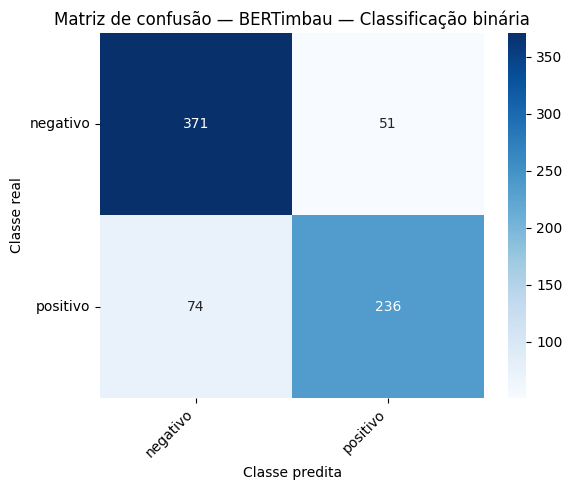

              precision    recall  f1-score   support

    negativo       0.83      0.88      0.86       422
    positivo       0.82      0.76      0.79       310

    accuracy                           0.83       732
   macro avg       0.83      0.82      0.82       732
weighted avg       0.83      0.83      0.83       732

\n ================================================================================ \nTreinamento BERT: multiclasse


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT multiclasse — época 1/3:   0%|          | 0/46 [00:00<?, ?it/s]

Época 1/3 | loss treino=1.8923 | loss val=1.7770 | acc val=0.2685 | F1 macro val=0.2421


BERT multiclasse — época 2/3:   0%|          | 0/46 [00:00<?, ?it/s]

Época 2/3 | loss treino=1.6633 | loss val=1.5911 | acc val=0.3813 | F1 macro val=0.3639


BERT multiclasse — época 3/3:   0%|          | 0/46 [00:00<?, ?it/s]

Época 3/3 | loss treino=1.5022 | loss val=1.5190 | acc val=0.4008 | F1 macro val=0.3894


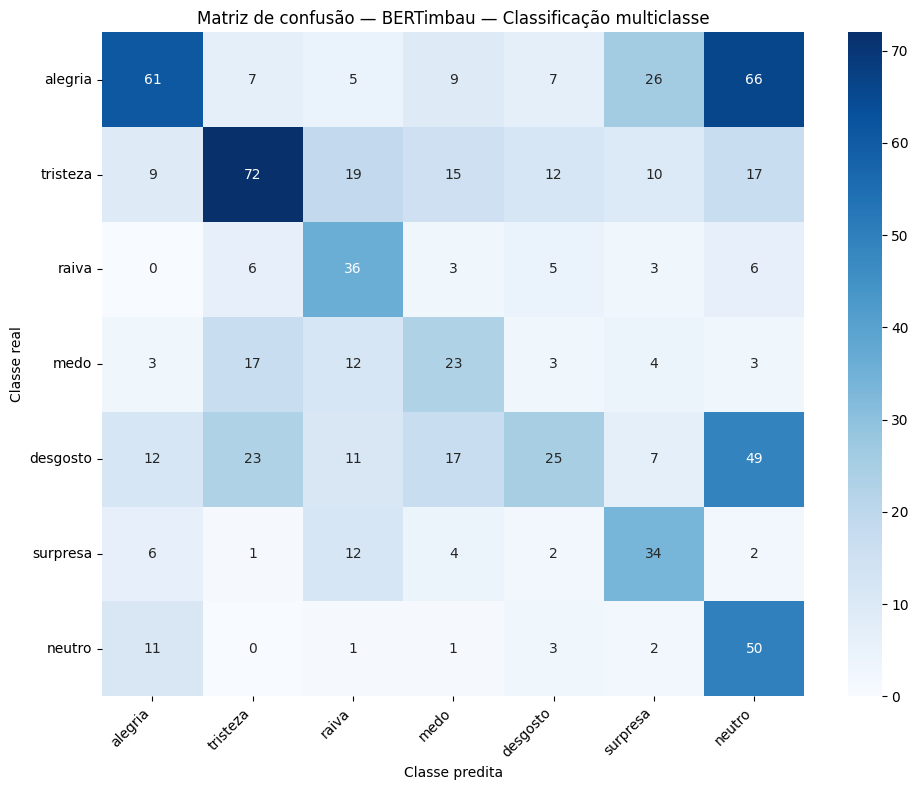

              precision    recall  f1-score   support

     alegria       0.60      0.34      0.43       181
    tristeza       0.57      0.47      0.51       154
       raiva       0.38      0.61      0.46        59
        medo       0.32      0.35      0.34        65
    desgosto       0.44      0.17      0.25       144
    surpresa       0.40      0.56      0.46        61
      neutro       0.26      0.74      0.38        68

    accuracy                           0.41       732
   macro avg       0.42      0.46      0.41       732
weighted avg       0.47      0.41      0.41       732



In [17]:
resultados_bert = {}

for chave_tarefa in [
    "binaria",
    "multiclasse",
]:
    print(
        "\\n",
        "=" * 80,
        "\\nTreinamento BERT:",
        chave_tarefa,
    )

    modelo_bert, linha = (
        treinar_bert(
            chave_tarefa
        )
    )

    resultados_bert[
        chave_tarefa
    ] = linha

    del modelo_bert
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## 18. Curvas de treinamento do BERT

Visualização do F1 macro e da perda de validação por época.

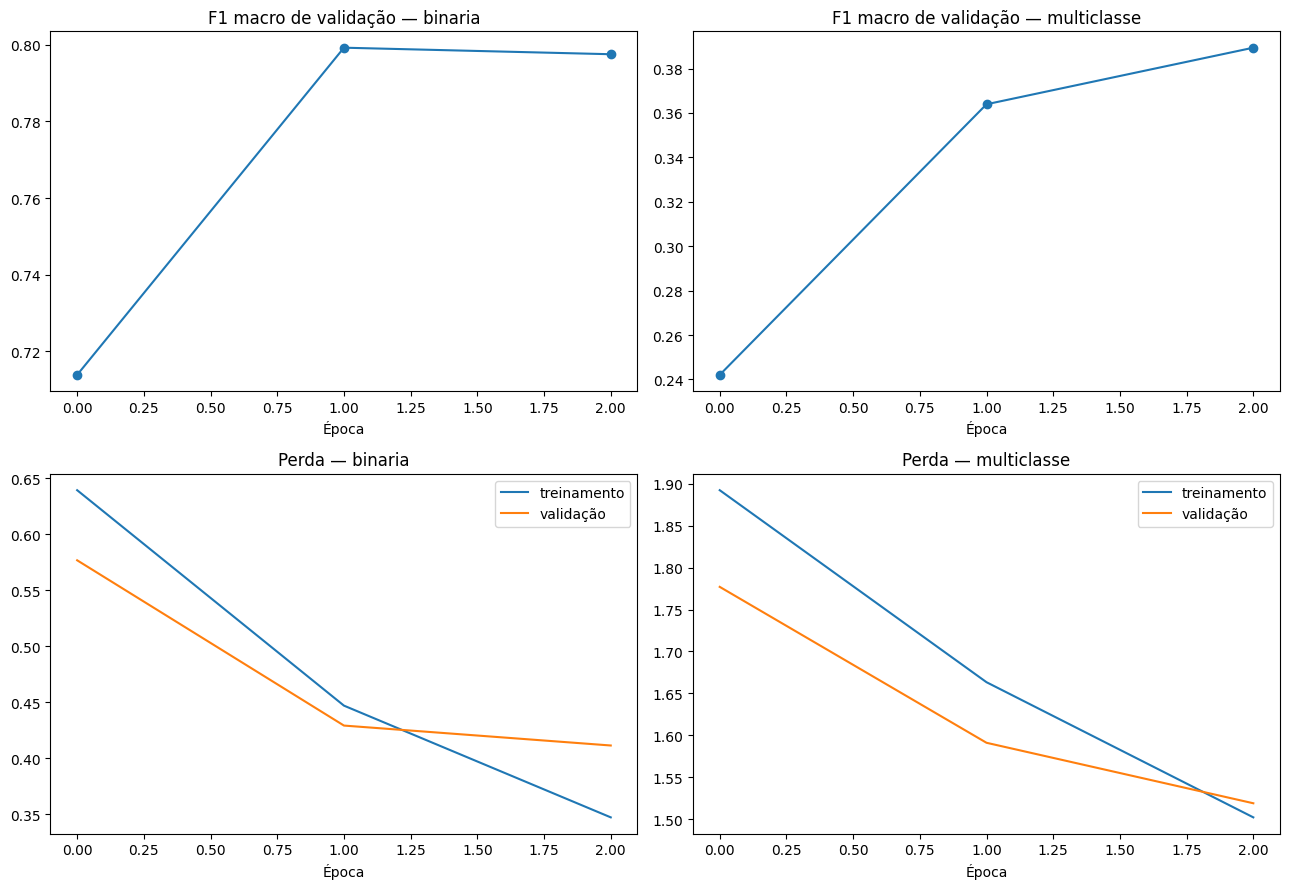

In [18]:
fig, eixos = plt.subplots(
    2,
    2,
    figsize=(13, 9),
)

for coluna, chave_tarefa in enumerate([
    "binaria",
    "multiclasse",
]):
    historico = historicos[
        (chave_tarefa, "BERTimbau")
    ]

    eixos[0, coluna].plot(
        historico[
            "f1_validacao"
        ],
        marker="o",
    )
    eixos[0, coluna].set_title(
        f"F1 macro de validação — {chave_tarefa}"
    )
    eixos[0, coluna].set_xlabel(
        "Época"
    )

    eixos[1, coluna].plot(
        historico[
            "perda_treino"
        ],
        label="treinamento",
    )
    eixos[1, coluna].plot(
        historico[
            "perda_validacao"
        ],
        label="validação",
    )
    eixos[1, coluna].set_title(
        f"Perda — {chave_tarefa}"
    )
    eixos[1, coluna].set_xlabel(
        "Época"
    )
    eixos[1, coluna].legend()

plt.tight_layout()
plt.show()

# Consolidação e comparação

## 19. Tabela final

Comparação direta entre LSTM e BERTimbau para as duas tarefas. Ordenação por tarefa e F1 macro.

In [19]:
df_resultados = pd.DataFrame(
    resultados
)

df_resultados = (
    df_resultados
    .drop_duplicates(
        subset=[
            "tarefa",
            "modelo",
        ],
        keep="last",
    )
    .sort_values(
        by=[
            "tarefa",
            "f1_macro",
            "acuracia",
        ],
        ascending=[
            True,
            False,
            False,
        ],
    )
    .reset_index(
        drop=True
    )
)

colunas_exibicao = [
    "descricao_tarefa",
    "modelo",
    "acuracia",
    "f1_macro",
    "f1_ponderado",
    "precisao_macro",
    "recall_macro",
    "tempo_segundos",
]

display(
    df_resultados[
        colunas_exibicao
    ].style.format({
        "acuracia": "{:.4f}",
        "f1_macro": "{:.4f}",
        "f1_ponderado": "{:.4f}",
        "precisao_macro": "{:.4f}",
        "recall_macro": "{:.4f}",
        "tempo_segundos": "{:.1f}",
    })
)

df_resultados.to_csv(
    PASTA_SAIDA
    / "resultados_lstm_bert.csv",
    index=False,
)

metadados_execucao = {
    "versao_notebook": VERSAO_NOTEBOOK,
    "modo_rapido": MODO_RAPIDO,
    "semente": SEMENTE,
    "tensorflow": tf.__version__,
    "pandas": pd.__version__,
    "torch": torch.__version__,
    "transformers": transformers.__version__,
    "huggingface_hub": package_version(
        "huggingface-hub"
    ),
    "dispositivo": str(DISPOSITIVO),
    "gpu": NOME_GPU,
    "vram_gb": VRAM_GB,
    "modelo_bert": MODELO_BERT,
    "batch_lstm": BATCH_LSTM,
    "batch_bert": BATCH_BERT,
    "epocas_lstm": EPOCAS_LSTM,
    "epocas_bert": EPOCAS_BERT,
    "arquivos": {
        chave: str(valor)
        for chave, valor
        in caminhos.items()
    },
}

with open(
    PASTA_SAIDA
    / "metadados_execucao.json",
    "w",
    encoding="utf-8",
) as arquivo:
    json.dump(
        metadados_execucao,
        arquivo,
        ensure_ascii=False,
        indent=2,
    )

,descricao_tarefa,modelo,acuracia,f1_macro,f1_ponderado,precisao_macro,recall_macro,tempo_segundos
0,Classificação binária,BERTimbau,0.8292,0.8232,0.8282,0.8280,0.8202,5.5
1,Classificação binária,LSTM,0.7473,0.7467,0.7485,0.7525,0.7577,7.6
2,Classificação multiclasse,BERTimbau,0.4112,0.4057,0.4051,0.4224,0.4621,6.2
3,Classificação multiclasse,LSTM,0.1831,0.1175,0.1059,0.0957,0.2481,7.5


## 20. Melhor modelo por tarefa

Seleção pelo maior F1 macro. Apresentação da diferença de acurácia e F1 entre BERTimbau e LSTM.

In [20]:
comparacoes = []

for chave_tarefa in [
    "binaria",
    "multiclasse",
]:
    tabela_tarefa = (
        df_resultados[
            df_resultados[
                "tarefa"
            ]
            == chave_tarefa
        ]
        .copy()
        .sort_values(
            by=[
                "f1_macro",
                "acuracia",
            ],
            ascending=False,
        )
    )

    melhor = (
        tabela_tarefa.iloc[0]
    )

    lstm = (
        tabela_tarefa[
            tabela_tarefa[
                "modelo"
            ]
            == "LSTM"
        ]
        .iloc[0]
    )

    bert = (
        tabela_tarefa[
            tabela_tarefa[
                "modelo"
            ]
            == "BERTimbau"
        ]
        .iloc[0]
    )

    comparacoes.append({
        "tarefa": chave_tarefa,
        "melhor_modelo": melhor["modelo"],
        "melhor_f1_macro": melhor["f1_macro"],
        "melhor_acuracia": melhor["acuracia"],
        "diferenca_acuracia_bert_menos_lstm": (
            bert["acuracia"]
            - lstm["acuracia"]
        ),
        "diferenca_f1_bert_menos_lstm": (
            bert["f1_macro"]
            - lstm["f1_macro"]
        ),
    })

df_comparacoes = pd.DataFrame(
    comparacoes
)

display(
    df_comparacoes.style.format({
        "melhor_f1_macro": "{:.4f}",
        "melhor_acuracia": "{:.4f}",
        "diferenca_acuracia_bert_menos_lstm": "{:+.4f}",
        "diferenca_f1_bert_menos_lstm": "{:+.4f}",
    })
)

,tarefa,melhor_modelo,melhor_f1_macro,melhor_acuracia,diferenca_acuracia_bert_menos_lstm,diferenca_f1_bert_menos_lstm
0,binaria,BERTimbau,0.8232,0.8292,+0.0820,+0.0765
1,multiclasse,BERTimbau,0.4057,0.4112,+0.2281,+0.2882


## 21. Exemplos de divergência entre os modelos

Inspeção de textos classificados corretamente por apenas um dos modelos. Recurso útil para discussão qualitativa das diferenças entre recorrência e atenção contextual.

In [21]:
def mostrar_divergencias(
    chave_tarefa,
    limite=10,
):
    tarefa = tarefas[
        chave_tarefa
    ]

    pred_lstm = predicoes[
        (
            chave_tarefa,
            "LSTM",
        )
    ]

    pred_bert = predicoes[
        (
            chave_tarefa,
            "BERTimbau",
        )
    ]

    y_real = tarefa[
        "y_teste"
    ]

    divergencias = pd.DataFrame({
        "texto": tarefa[
            "textos_teste"
        ],
        "real": [
            tarefa["classes"][i]
            for i in y_real
        ],
        "LSTM": [
            tarefa["classes"][i]
            for i in pred_lstm
        ],
        "BERTimbau": [
            tarefa["classes"][i]
            for i in pred_bert
        ],
        "LSTM_correto": (
            pred_lstm == y_real
        ),
        "BERT_correto": (
            pred_bert == y_real
        ),
    })

    divergencias = divergencias[
        divergencias[
            "LSTM_correto"
        ]
        != divergencias[
            "BERT_correto"
        ]
    ]

    return divergencias.head(
        limite
    )

display(
    mostrar_divergencias(
        "binaria"
    )
)

display(
    mostrar_divergencias(
        "multiclasse"
    )
)

,texto,real,LSTM,BERTimbau,LSTM_correto,BERT_correto
1,Ney Latorraca melhora e pode deixar CTI na pró...,positivo,positivo,negativo,True,False
3,Aécio Neves defende reforma profunda no Senado...,positivo,positivo,negativo,True,False
5,"Após superar US$ 73, petróleo fecha em baixa e...",positivo,positivo,negativo,True,False
6,Obras e má sinalização aumentam acidentes em e...,negativo,positivo,negativo,False,True
19,"Centrais fazem 1º de maio com shows, prêmios e...",positivo,positivo,negativo,True,False
20,Jornalista que ficou presa no Irã encontra Hil...,negativo,positivo,negativo,False,True
27,Ministério Público reprova contas da Fundação ...,negativo,positivo,negativo,False,True
29,Obras e má sinalização aumentam acidentes em e...,negativo,positivo,negativo,False,True
30,Instalação da CPI da Petrobras não tem data pa...,negativo,positivo,negativo,False,True
33,"Após cirurgia, Severino Cavalcanti terá alta d...",positivo,positivo,negativo,True,False


,texto,real,LSTM,BERTimbau,LSTM_correto,BERT_correto
0,Chinês ergue 5 kg usando apenas as pálpebras. ...,surpresa,raiva,surpresa,False,True
2,Acidente entre van e caminhão deixa 2 mortos e...,tristeza,raiva,tristeza,False,True
4,"Verissimo vem respondendo bem ao tratamento, d...",tristeza,tristeza,alegria,True,False
5,Teste em simulador mostra os riscos de dirigir...,surpresa,neutro,surpresa,False,True
10,Perspectivas para atividade econômica seguem m...,alegria,neutro,alegria,False,True
17,Atentados matam 15 e ferem dezenas no Iraque. ...,tristeza,raiva,tristeza,False,True
21,Obama mexe na agenda e faz parada por um hambú...,alegria,neutro,alegria,False,True
23,Cabeça gigante é achada boiando em rio e gera ...,surpresa,raiva,surpresa,False,True
25,Passa de 100 o total de mortos por Sandy no mu...,tristeza,raiva,tristeza,False,True
30,Fiorella Mattheis foge de arrastão no Rio: Eu ...,medo,tristeza,medo,False,True


# Relatório em PDF

## 22. Geração automática

Criação de relatório contendo:

- descrição da base e do tratamento de duplicatas;
- protocolo holdout 70%/30%;
- tabela de métricas;
- comparação LSTM versus BERTimbau;
- quatro matrizes de confusão;
- conclusão para a tarefa binária e para a multiclasse;
- links relativos para o notebook e para o exemplo LSTM.

Manutenção do PDF e dos notebooks no mesmo diretório para funcionamento dos links locais.

In [22]:
from reportlab.lib import colors
from reportlab.lib.enums import (
    TA_CENTER,
)
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import (
    getSampleStyleSheet,
    ParagraphStyle,
)
from reportlab.lib.units import cm
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    PageBreak,
    Image as RLImage,
)

CAMINHO_RELATORIO = (
    PASTA_SAIDA
    / "relatorio_atividade_2_lstm_transformer.pdf"
)

styles = getSampleStyleSheet()

styles.add(
    ParagraphStyle(
        name="TituloAtividade2",
        parent=styles["Title"],
        alignment=TA_CENTER,
        fontSize=19,
        leading=23,
        spaceAfter=12,
        textColor=colors.HexColor(
            "#0F172A"
        ),
    )
)

styles.add(
    ParagraphStyle(
        name="SubtituloAtividade2",
        parent=styles["Normal"],
        alignment=TA_CENTER,
        fontSize=10,
        leading=14,
        spaceAfter=16,
        textColor=colors.HexColor(
            "#475569"
        ),
    )
)

styles.add(
    ParagraphStyle(
        name="TextoAtividade2",
        parent=styles["BodyText"],
        fontSize=9.2,
        leading=13.5,
        spaceAfter=7,
    )
)

documento = SimpleDocTemplate(
    str(CAMINHO_RELATORIO),
    pagesize=A4,
    rightMargin=1.5 * cm,
    leftMargin=1.5 * cm,
    topMargin=1.4 * cm,
    bottomMargin=1.4 * cm,
)

historia = []

historia.append(
    Paragraph(
        "Atividade 2 — Classificação de emoções",
        styles["TituloAtividade2"],
    )
)

historia.append(
    Paragraph(
        "Comparação entre LSTM e BERTimbau em tarefas binária e multiclasse",
        styles["SubtituloAtividade2"],
    )
)

historia.append(
    Paragraph(
        "<b>Base de dados.</b> Concatenação dos arquivos "
        "<code>g1_v1_ws.csv</code> e <code>g1_v2_ws.csv</code>. "
        f"Quantidade bruta: {len(df_bruto)} registros. "
        f"Quantidade após limpeza: {len(df)} registros.",
        styles["TextoAtividade2"],
    )
)

historia.append(
    Paragraph(
        "<b>Protocolo.</b> Holdout estratificado com 70% para treinamento "
        "e 30% para teste. Reserva interna de validação apenas dentro dos "
        "70% de treinamento. Avaliação final por acurácia, F1 macro, "
        "F1 ponderado e matriz de confusão.",
        styles["TextoAtividade2"],
    )
)

historia.append(
    Paragraph(
        "<b>Scripts.</b> "
        '<link href="atividade_2_lstm_transformer_emocoes_refatorado_v2.ipynb">'
        "Notebook principal</link> | "
        '<link href="Text_Classification_LSTM_emotions_binary.ipynb">'
        "Notebook LSTM de referência</link>",
        styles["TextoAtividade2"],
    )
)

historia.append(
    Paragraph(
        "Resultados",
        styles["Heading1"],
    )
)

dados_tabela = [[
    "Tarefa",
    "Modelo",
    "Acurácia",
    "F1 macro",
    "F1 ponderado",
    "Tempo (s)",
]]

for _, linha in df_resultados.iterrows():
    dados_tabela.append([
        Paragraph(
            str(
                linha[
                    "descricao_tarefa"
                ]
            ),
            styles[
                "TextoAtividade2"
            ],
        ),
        linha["modelo"],
        f'{linha["acuracia"]:.4f}',
        f'{linha["f1_macro"]:.4f}',
        f'{linha["f1_ponderado"]:.4f}',
        f'{linha["tempo_segundos"]:.1f}',
    ])

tabela = Table(
    dados_tabela,
    colWidths=[
        4.2 * cm,
        2.6 * cm,
        2.4 * cm,
        2.4 * cm,
        2.5 * cm,
        2.3 * cm,
    ],
    repeatRows=1,
)

tabela.setStyle(
    TableStyle([
        (
            "BACKGROUND",
            (0, 0),
            (-1, 0),
            colors.HexColor(
                "#1D4ED8"
            ),
        ),
        (
            "TEXTCOLOR",
            (0, 0),
            (-1, 0),
            colors.white,
        ),
        (
            "FONTNAME",
            (0, 0),
            (-1, 0),
            "Helvetica-Bold",
        ),
        (
            "FONTSIZE",
            (0, 0),
            (-1, -1),
            8,
        ),
        (
            "ALIGN",
            (1, 1),
            (-1, -1),
            "CENTER",
        ),
        (
            "VALIGN",
            (0, 0),
            (-1, -1),
            "MIDDLE",
        ),
        (
            "GRID",
            (0, 0),
            (-1, -1),
            0.4,
            colors.HexColor(
                "#CBD5E1"
            ),
        ),
        (
            "ROWBACKGROUNDS",
            (0, 1),
            (-1, -1),
            [
                colors.white,
                colors.HexColor(
                    "#F8FAFC"
                ),
            ],
        ),
        (
            "TOPPADDING",
            (0, 0),
            (-1, -1),
            5,
        ),
        (
            "BOTTOMPADDING",
            (0, 0),
            (-1, -1),
            5,
        ),
    ])
)

historia.append(tabela)
historia.append(Spacer(1, 10))

for _, comparacao in df_comparacoes.iterrows():
    chave_tarefa = comparacao[
        "tarefa"
    ]

    titulo = tarefas[
        chave_tarefa
    ]["nome"]

    historia.append(
        Paragraph(
            titulo,
            styles["Heading1"],
        )
    )

    historia.append(
        Paragraph(
            f"Melhor modelo pelo F1 macro: "
            f"<b>{comparacao['melhor_modelo']}</b>. "
            f"Acurácia={comparacao['melhor_acuracia']:.4f}; "
            f"F1 macro={comparacao['melhor_f1_macro']:.4f}. "
            f"Diferença BERT−LSTM em acurácia="
            f"{comparacao['diferenca_acuracia_bert_menos_lstm']:+.4f}; "
            f"diferença BERT−LSTM em F1 macro="
            f"{comparacao['diferenca_f1_bert_menos_lstm']:+.4f}.",
            styles["TextoAtividade2"],
        )
    )

    for modelo in [
        "LSTM",
        "BERTimbau",
    ]:
        linha_modelo = df_resultados[
            (
                df_resultados[
                    "tarefa"
                ]
                == chave_tarefa
            )
            & (
                df_resultados[
                    "modelo"
                ]
                == modelo
            )
        ].iloc[0]

        caminho_imagem = Path(
            linha_modelo[
                "caminho_matriz"
            ]
        )

        historia.append(
            Paragraph(
                f"Matriz de confusão — {modelo}",
                styles["Heading2"],
            )
        )

        if caminho_imagem.exists():
            largura = (
                11.5 * cm
                if chave_tarefa
                == "binaria"
                else 16.5 * cm
            )

            altura = (
                9.0 * cm
                if chave_tarefa
                == "binaria"
                else 13.2 * cm
            )

            historia.append(
                RLImage(
                    str(
                        caminho_imagem
                    ),
                    width=largura,
                    height=altura,
                )
            )

    historia.append(PageBreak())

historia.append(
    Paragraph(
        "Conclusão",
        styles["Heading1"],
    )
)

historia.append(
    Paragraph(
        "A comparação utiliza a mesma divisão de teste para os dois modelos "
        "em cada tarefa. A LSTM aprende o vocabulário e os embeddings apenas "
        "com a base da atividade. O BERTimbau parte de representações "
        "contextuais pré-treinadas em português. As diferenças observadas "
        "devem ser interpretadas em conjunto com o F1 macro e as confusões "
        "entre as emoções minoritárias.",
        styles["TextoAtividade2"],
    )
)

documento.build(
    historia
)

print(
    "Relatório criado:",
    CAMINHO_RELATORIO.resolve(),
)

Relatório criado: /content/drive/MyDrive/atividade_2_lstm_transformer/resultados/v2.0.0/relatorio_atividade_2_lstm_transformer.pdf


## 23. Arquivos produzidos

Ao final da execução completa, a pasta `resultados_atividade_2` contém:

- modelos LSTM;
- pesos dos dois BERTs;
- matrizes de confusão;
- tabela CSV de resultados;
- relatório final em PDF.

In [23]:
for arquivo in sorted(
    PASTA_SAIDA.iterdir()
):
    print(
        arquivo.name
    )

bert_binaria.pt
bert_binaria_historico.json
bert_binaria_loading_info.json
bert_multiclasse.pt
bert_multiclasse_historico.json
bert_multiclasse_loading_info.json
lstm_binaria.keras
lstm_binaria_melhor.keras
lstm_binaria_treinamento.csv
lstm_multiclasse.keras
lstm_multiclasse_melhor.keras
lstm_multiclasse_treinamento.csv
matriz_Classifica_o_bin_ria_BERTimbau.png
matriz_Classifica_o_bin_ria_LSTM.png
matriz_Classifica_o_multiclasse_BERTimbau.png
matriz_Classifica_o_multiclasse_LSTM.png
metadados_execucao.json
predicoes_parciais.npz
relatorio_atividade_2_lstm_transformer.pdf
resultados_lstm_bert.csv
resultados_parciais.csv
